In [ ]:
import numpy as np
import pandas as pd
import os

In [ ]:
def load_swc(filepath):
    cols = ["id", "type", "x", "y", "z", "r", "parent"]
    df = pd.read_csv(filepath, sep=r"\s+", comment="#", names=cols)
    return df

In [ ]:
def get_soma(df):
    soma = df[df["type"] == 1].iloc[0]
    return np.array([soma.x, soma.y, soma.z])


def get_dendrite_segments(df):
    dendrite = df[df["type"].isin([3])]

    segments = []
    for _, row in dendrite.iterrows():
        if row.parent == -1:
            continue

        parent = df[df["id"] == row.parent]
        if parent.empty:
            continue

        p1 = np.array([row.x, row.y, row.z])
        p2 = parent[["x", "y", "z"]].values[0]

        segments.append((p1, p2))

    return segments,dendrite

In [ ]:
def segment_crosses_sphere(p1, p2, center, radius):
    d1 = np.linalg.norm(p1 - center)
    d2 = np.linalg.norm(p2 - center)

    # 一内一外 → 穿过
    return (d1 < radius and d2 >= radius) or (d1 >= radius and d2 < radius)

In [ ]:
def sholl_analysis(df, step=10, max_radius=None):
    soma = get_soma(df)
    segments,dendrite = get_dendrite_segments(df)

    # 自动确定最大半径
    if max_radius is None:

        coords = dendrite[["x", "y", "z"]].values
        max_radius = np.max(np.linalg.norm(coords - soma, axis=1))

    radii = np.arange(step, max_radius, step)
    counts = []

    for r in radii:
        count = 0
        for p1, p2 in segments:
            if segment_crosses_sphere(p1, p2, soma, r):
                count += 1
        counts.append(count)

    return radii, counts

In [ ]:
import matplotlib.pyplot as plt

def plot_sholl(radii, counts,figname):
    plt.figure()
    plt.plot(radii, counts, marker='o')
    plt.xlabel("Radius (µm)")
    plt.ylabel("Intersections")
    plt.title("%s Sholl Analysis"%figname)
    plt.savefig(figname+".jpg",dpi = 300)
    # plt.show()

In [ ]:
os.chdir(r"J:\BLA_Cck\soma_sholl")

In [ ]:
import glob
from tqdm import tqdm
swcs = glob.glob(r"J:\BLA_Cck\BLA_swc_mirrow\*")

In [ ]:
for swc in tqdm(swcs):
    neuron = swc.split("\\")[-1][0:-4]
    df = load_swc(swc)
    radii, counts = sholl_analysis(df, step=10)
    dftmp = pd.DataFrame(counts,index=radii,columns = [neuron])
    dftmp.to_csv(neuron+".csv")
    figname = neuron
    plot_sholl(radii, counts,figname)


In [ ]:
files = glob.glob(r"J:\BLA_Cck\soma_sholl\raw\*.csv")
dfall = pd.DataFrame()
for file in files:
    # print(file)
    df = pd.read_csv(file,index_col=0)
    dfall = pd.concat([dfall,df],axis=1)
dfall = dfall.fillna(0).T
dfall.to_csv("all_neurons_sholl.csv")

In [ ]:
files

In [ ]:
dfc = pd.read_csv("all_terminal_infor_table_dendrite_intensity_cluster.csv",index_col=0)
dfall2 = pd.concat([dfc[["cluster"]],dfall],axis=1)
dfall2.to_csv("all_neurons_sholl_cluster.csv")

In [ ]:
dfall2 = dfall2.reset_index()

In [ ]:
df_long = dfall2.melt(
    id_vars=['index', 'cluster'],  # 保留 sample 和 cluster
    var_name='x',                  # 原来的 10,20,30 → x
    value_name='value'             # 数值
)
df_long2 = df_long.loc[df_long.x<=300]
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rc("font",family="Arial")

plt.figure(figsize=(8,4))

dic_list = {1: 'hotpink', 3: 'lime', 2: 'steelblue'}

sns.lineplot(
    data=df_long2,
    x='x',          # 横轴
    y='value',      # 纵轴
    hue='cluster',  # 按 cluster 分组
    marker='.',
    palette = dic_list
)

plt.ylabel("Number of intersections")
plt.xlabel("Radius from soma (µm)")
plt.title('sholl analysis')
plt.savefig("sholl analysis.pdf",dpi=300)
plt.savefig("sholl analysis.jpg",dpi=300)

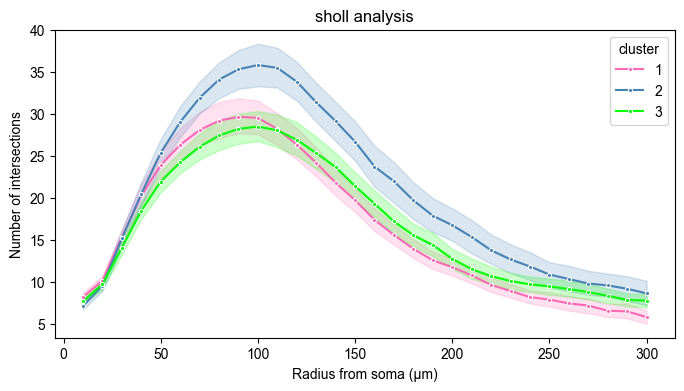

In [ ]:
df = load_swc("251038_001.swc")

radii, counts = sholl_analysis(df, step=10)

plot_sholl(radii, counts)

In [ ]:
radii